# Fink Solar System statistics

This tutorial shows how to get progammatically statistics about the LSST alert stream using Fink API. 

````{note} API & documentation
Full documentation is at https://doc.lsst.fink-broker.org/services/api/statistics/, and endpoint can be found at https://api.lsst.fink-portal.org
````

In [2]:
import datetime
import io

import matplotlib.pyplot as plt

plt.rcParams.update({"font.size": 15})

import pandas as pd
import requests


def make_date_for_plot(indate):
    """Change int(YYYYMMDD) to datetime object

    Parameters
    ----------
    indate: int, or str
        Integer or string of the form YYYYDDMM

    Returns
    -------
    out: datetime
    """
    if not isinstance(indate, str):
        indate = str(indate)
    return datetime.date.fromisoformat(
        indate[0:4] + "-" + indate[4:6] + "-" + indate[6:]
    )

In [3]:
# Get all statistics for 2026
r = requests.post(
    "https://api.lsst.fink-portal.org/api/v1/statistics",
    json={"date": "2026", "output-format": "json"},
)

# Format output in a DataFrame
pdf = pd.read_json(io.BytesIO(r.content))

In [4]:
pdf

,f:alerts,f:alerts_g,f:alerts_i,f:alerts_r,f:alerts_u,f:alerts_y,f:alerts_z,f:fink_broker_version,f:fink_science_version,f:glint_trail,...,f:is_cataloged,f:is_first,f:is_sso,f:lsst_schema_version,f:objects,f:pixelFlags_cr,f:pixelFlags_saturated,f:pixelFlags_streak,f:visits,f:night
0,12276,0,12276,0,0,0,0,4.1,8.39.0,12276,...,0,9200,0,lsst.v10_0,10246,12276,12276,12276,16,20260101
1,12642,0,12642,0,0,0,0,4.1,8.39.0,12642,...,0,9909,0,lsst.v10_0,11462,12642,12642,12642,18,20260102
2,8822,2413,3504,0,0,2905,0,4.1,8.39.0,8822,...,0,7015,0,lsst.v10_0,7997,8822,8822,8822,14,20260103
3,8416,0,0,4024,0,0,4392,4.1,8.39.0,8416,...,0,6571,0,lsst.v10_0,8013,8416,8416,8416,12,20260104
4,9411,3586,5825,0,0,0,0,4.1,8.39.0,9411,...,0,6786,0,lsst.v10_0,8768,9411,9411,9411,8,20260105
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
90,227916,1228,154477,21525,0,0,50686,5.0rc0,8.52.0,227916,...,122154,119514,22859,lsst.v11_1,185240,227916,227916,227916,89,20260710
91,125442,2210,70512,52720,0,0,0,5.0rc0,8.52.0,125442,...,48071,53591,29197,lsst.v11_1,83024,125442,125442,125442,87,20260711
92,71683,4255,43264,24164,0,0,0,5.0rc0,8.52.0,71683,...,20165,34259,11262,lsst.v11_1,54893,71683,71683,71683,38,20260712
93,744559,34501,264297,187532,0,0,258229,5.0rc0,8.52.0,744559,...,339250,487906,12544,lsst.v11_1,677429,744559,744559,744559,82,20260713


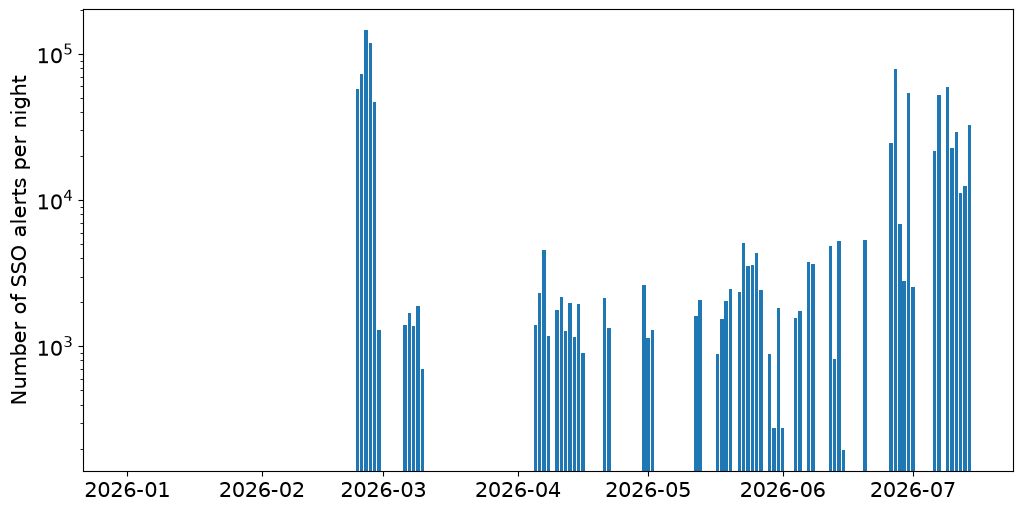

In [5]:
fig = plt.figure(figsize=(12, 6))
plt.bar(x=pdf["f:night"].apply(make_date_for_plot), height=pdf["f:is_sso"])
plt.yscale("log")
plt.ylabel("Number of SSO alerts per night");

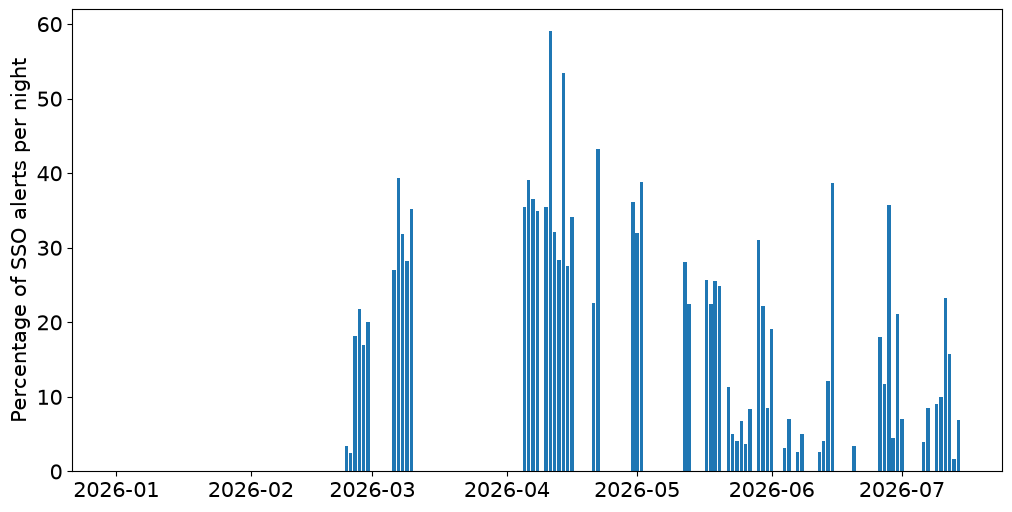

In [6]:
fig = plt.figure(figsize=(12, 6))
plt.bar(
    x=pdf["f:night"].apply(make_date_for_plot),
    height=pdf["f:is_sso"] / pdf["f:alerts"] * 100,
)
plt.ylabel("Percentage of SSO alerts per night");

In [7]:
fraction = pdf["f:is_sso"] / pdf["f:alerts"] * 100
mask = fraction > 0  # only nights with SSO reported
print(
    f"SSO alerts represent about {(fraction[mask]).median():.1f}% of the stream each night (median)"
)

SSO alerts represent about 21.5% of the stream each night (median)
